<a href="https://colab.research.google.com/github/Madhushali04/heart-disease-prediction/blob/main/heart-disease/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo



# fetch dataset

heart_disease = fetch_ucirepo(id=45)


# data (as pandas dataframes)

X = heart_disease.data.features

y = heart_disease.data.targets


# metadata

print(heart_disease.metadata)



# variable information

print(heart_disease.variables)






{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
print(X.isnull().sum())






age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


/tmp/ipykernel_1970/628518911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.iloc[:,0],palette ='RdYlGn')


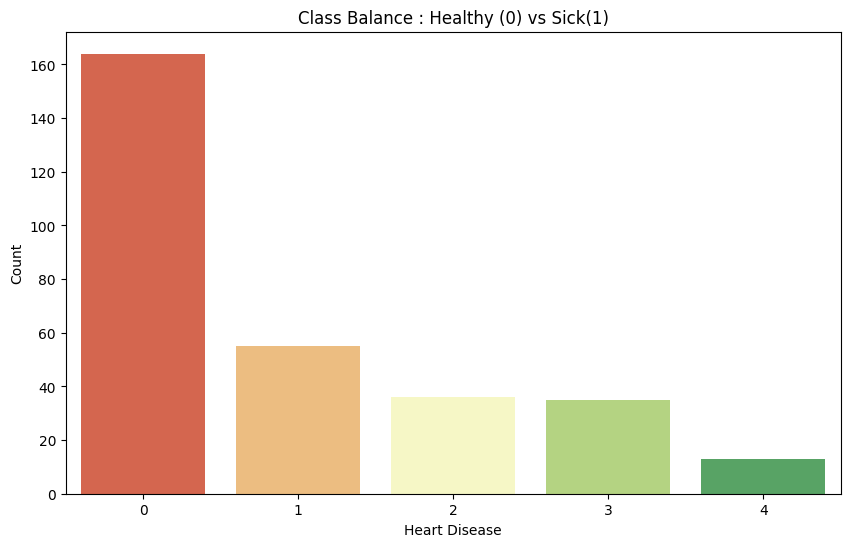

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plotting

plt.figure(figsize=(10, 6))

sns.countplot(x=y.iloc[:,0],palette ='RdYlGn')

plt.title('Class Balance : Healthy (0) vs Sick(1)')

plt.xlabel('Heart Disease')

plt.ylabel('Count')

plt.show()






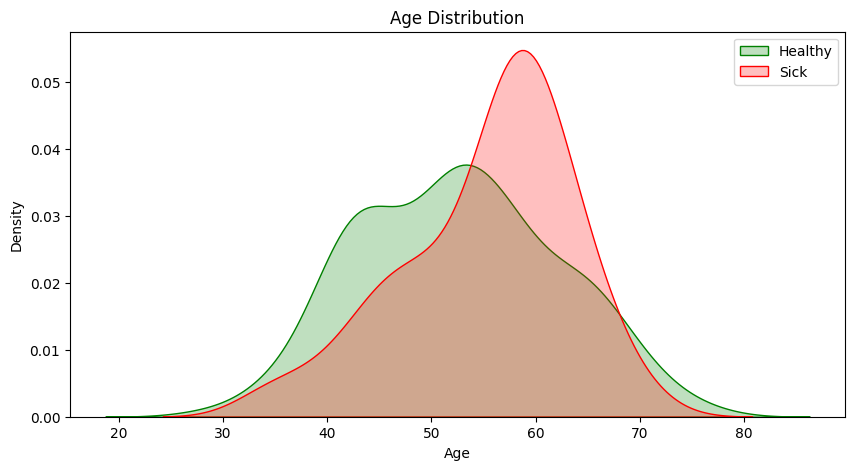

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(X[y.iloc[:, 0] == 0]['age'],label ="Healthy",fill=True, color='green')

sns.kdeplot(X[y.iloc[:, 0] == 1]['age'],label ="Sick",fill=True, color='red')

plt.title('Age Distribution')

plt.xlabel('Age')

plt.ylabel('Density')

plt.legend()






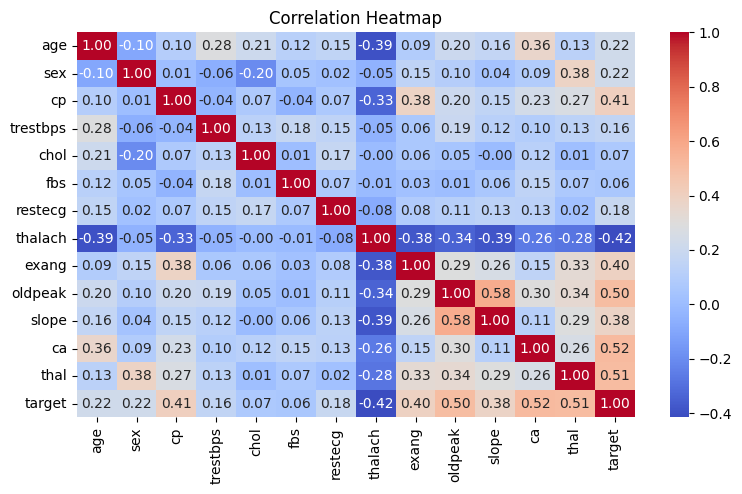

In [ ]:
# Heatmap

temp_df= X.copy()

temp_df['target'] = y

plt.figure(figsize=(9,5))

sns.heatmap(temp_df.corr(),annot = True, cmap ='coolwarm', fmt = '.2f')

plt.title('Correlation Heatmap')

plt.show()






In [ ]:
from sklearn.model_selection import train_test_split

X_clean  = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X_clean,y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")

print(f"y_train shape: {y_train.shape}")

print(f"X_test shape: {X_test.shape}")

print(f"y_test shape: {y_test.shape}")






X_train shape: (242, 13)
y_train shape: (242, 1)
X_test shape: (61, 13)
y_test shape: (61, 1)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest classifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)






/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest classifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# calculate Training Accuracy

train_accuracy = model.score(X_train, y_train)

print(f"Training Accuracy: {train_accuracy}")

print(f"Testing Accuracy: {accuracy_score(y_test, y_pred)}")






/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Accuracy: 1.0
Testing Accuracy: 0.4918032786885246


In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.datasets import make_classification




